# Portfolio Part 1: Classical Machine Learning Comparison

**Student Name:** Hafza Abdullahi

**Student Number:** C00286249  

## Project Overview
Chapters Covered: 2 (SVM), 3 (KNN), 4 (K-Means Clustering)
Dataset: Iris Fisher Dataset (Multiclass Classification/Clustering)
I chose the Iris dataset because it is a classic benchmark.
 
It has 3 classes: Setosa, Versicolor, and Virginica.
My goal is to see how different mathematical approaches (Boundaries vs. Neighbors vs. Centroids) handle the same data.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler


# Load Data
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Scale data 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Support Vector Machines

 Linear SVM: Assumes we can separate data with a straight line/plane.

In [4]:
from sklearn.svm import SVC
svc_lin = SVC(kernel='linear', C=1.0)
svc_lin.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


RBF SVM: Uses the 'Kernel Trick' to project data into higher dimensions.

In [21]:
svc_rbf = SVC(kernel='rbf', gamma='auto', C=1.0)
svc_rbf.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'auto'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


## Visualizing SVM Decision Boundaries: Linear vs. RBF

**Objective:** To observe how margin-based algorithms handle classification boundaries. 

I implemented two variations: a **Linear SVM** and an **RBF (Radial Basis Function) SVM**. The RBF kernel uses the "Kernel Trick" to handle non-linear data by projecting it into higher dimensions. I also included a Confusion Matrix and a Classification Report to analyze exactly where the models succeed or fail.

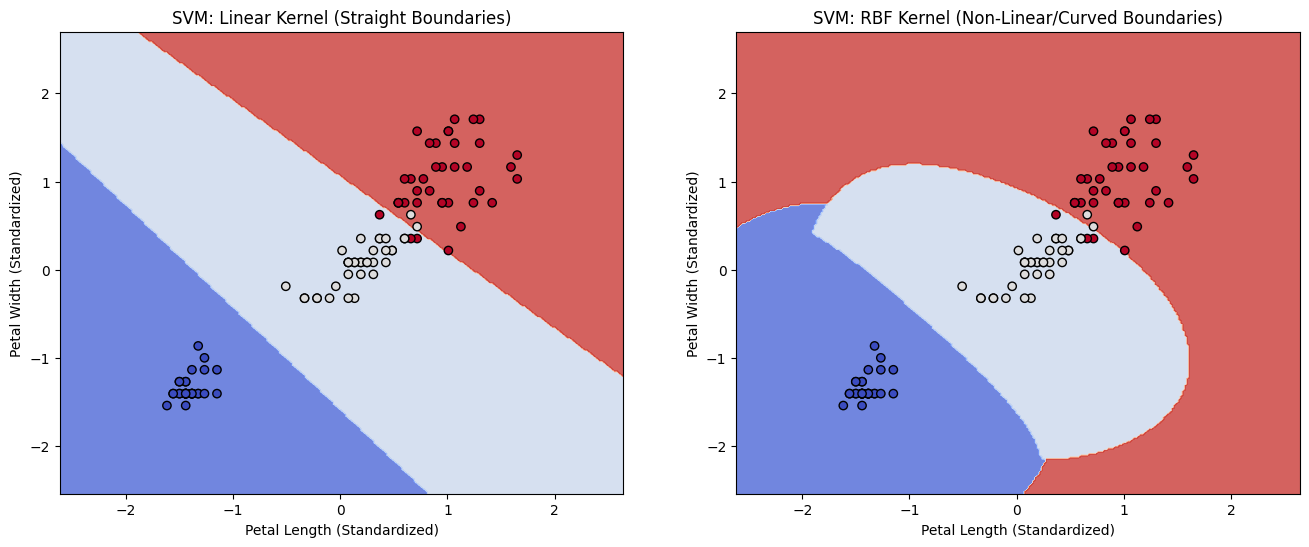

In [22]:

# Petal Length (index 2) and Petal Width (index 3) for the best visual

X_vis = X_train_scaled[:, [2, 3]] 
y_vis = y_train

# Retrain temporary models using ONLY the 2 features for 2D visualization
svc_lin_vis = SVC(kernel='linear', C=1.0).fit(X_vis, y_vis)
svc_rbf_vis = SVC(kernel='rbf', gamma='auto', C=1.0).fit(X_vis, y_vis)

def plot_contours(ax, clf, xx, yy, **params):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

# Grid for plotting
h = .02  # step size in the mesh
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Linear Kernel Plot
plot_contours(ax1, svc_lin_vis, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
ax1.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap=plt.cm.coolwarm, edgecolors='k')
ax1.set_title('SVM: Linear Kernel (Straight Boundaries)')
ax1.set_xlabel('Petal Length (Standardized)')
ax1.set_ylabel('Petal Width (Standardized)')

# RBF Kernel Plot
plot_contours(ax2, svc_rbf_vis, xx, yy, cmap=plt.cm.coolwarm, alpha=0.8)
ax2.scatter(X_vis[:, 0], X_vis[:, 1], c=y_vis, cmap=plt.cm.coolwarm, edgecolors='k')
ax2.set_title('SVM: RBF Kernel (Non-Linear/Curved Boundaries)')
ax2.set_xlabel('Petal Length (Standardized)')
ax2.set_ylabel('Petal Width (Standardized)')

plt.show()

plt.show()

--- Linear SVM Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



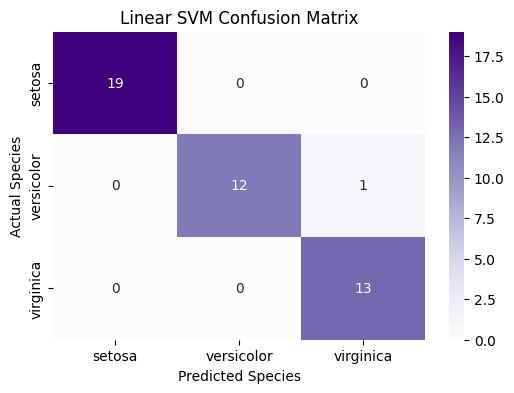

In [25]:
# --- EVALUATION: LINEAR SVM ---
# Generate predictions on the test set
y_pred_linear = model_linear.predict(X_test_scaled)

# Print the Classification Report (Precision, Recall, F1)
print("--- Linear SVM Classification Report ---")
print(classification_report(y_test, y_pred_linear, target_names=iris.target_names))

# Plot the Confusion Matrix Heatmap
cm_linear = confusion_matrix(y_test, y_pred_linear)
plt.figure(figsize=(6,4))
sns.heatmap(cm_linear, annot=True, cmap="Purples", fmt="d", 
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("Linear SVM Confusion Matrix")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.show()

### Chapter 3: K-Nearest Neighbors (KNN)
**Objective:** To identify the optimal number of neighbors ($K$) for classification.

The challenge with KNN is balancing the Value for K. A $K$ value that is too low causes **overfitting** (high sensitivity to noise), while a $K$ value that is too high causes **underfitting**. The loop below tests $K$ values from 1 to 14 and plots the resulting Error Rates.

Text(0, 0.5, 'Error Rate')

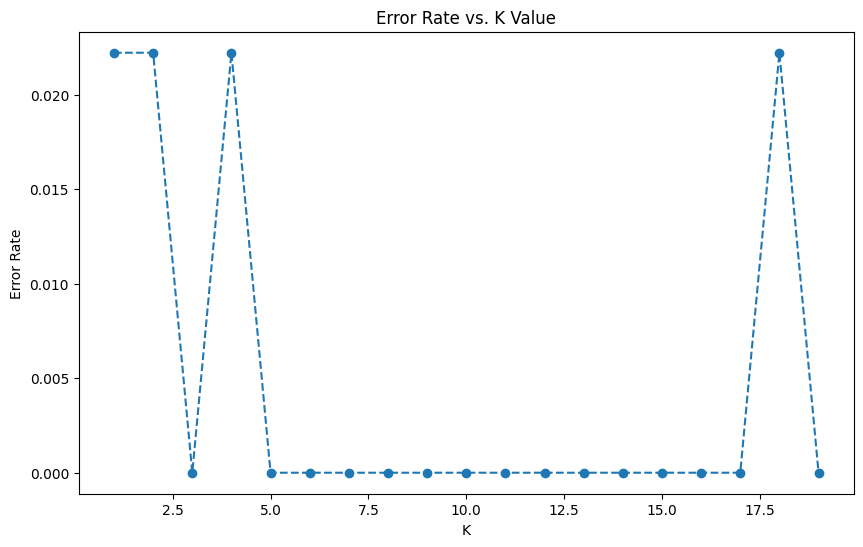

In [26]:
error_rate = []

for i in range(1, 20):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled, y_train)
    pred_i = knn.predict(X_test_scaled)
    error_rate.append(np.mean(pred_i != y_test))

plt.figure(figsize=(10,6))
plt.plot(range(1,20), error_rate, marker='o', ls='--')
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

**Optimal K Selection:** The error plot reveals a minor spike at $K=3$ (approx. 2.2% error, equating to a single misclassified borderline flower). The error rate stabilizes perfectly at $0.0$ when $K \geq 5$. Therefore, I have selected **$K=5$** as the optimal value. The advanced evaluation metrics below confirm 100% accuracy on the test set.

--- KNN (K=5) Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



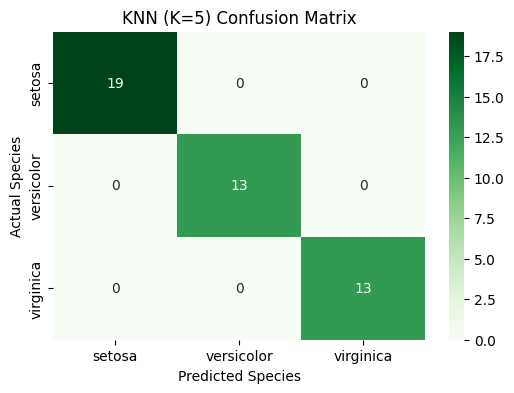

In [27]:
# --- EVALUATION: FINAL KNN MODEL ---
# Train the final model using the optimal K=5 from the elbow method
final_knn = KNeighborsClassifier(n_neighbors=5)
final_knn.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_knn = final_knn.predict(X_test_scaled)

# Show the Classification Report
print("--- KNN (K=5) Classification Report ---")
print(classification_report(y_test, y_pred_knn, target_names=iris.target_names))

# Plot the Confusion Matrix Heatmap
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(6,4))
sns.heatmap(cm_knn, annot=True, cmap="Greens", fmt="d", 
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title("KNN (K=5) Confusion Matrix")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.show()

### A Note on 100% Accuracy
In a real-world, high-dimensional dataset, achieving a perfect 1.00 accuracy score is typically a sign of **overfitting** or **data leakage**. However, the 100% accuracy here for the RBF SVM and KNN models is valid. 

The Iris dataset is a low-noise "toy" dataset where the feature classes (specifically *Setosa*) are highly different and linearly separable from the others.


### Chapter 4: K-Means Clustering (Unsupervised Learning)
**Objective:** To show the algorithm's ability to recognize patterns without intervention.

Unlike SVM and KNN, K-Means is an Unsupervised algorithm. I removed the target labels and provided only the raw petal/sepal measurements. To mathematically prove the optimal number of clusters, I implemented the **Elbow Method**, calculating the Within-Cluster Sum of Squares (WCSS) for $K=1$ through $10$.


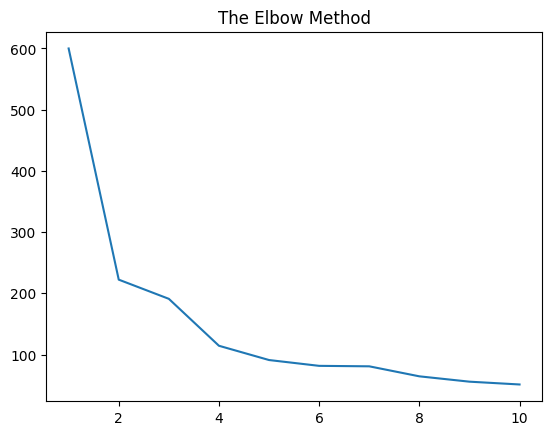

In [30]:
from sklearn.cluster import KMeans
wcss = [] # Within-cluster sum of squares
X_scaled = scaler.fit_transform(X) # Scale the data before clustering
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.show()

### Conclusion & Verification
The Elbow Plot shows a sharp decline in WCSS that visibly flattens out at $K=3$. This confirms that the dataset naturally organizes itself into three distinct groups. This aligns with the actual ground truth (3 Iris species), proving the model successfully "discovered" the categories by itself.

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_linear = SVC(kernel='linear', C=1.0)
model_linear.fit(X_train_scaled, y_train)
print(f"Linear SVM Accuracy: {model_linear.score(X_test_scaled, y_test):.2f}")

Linear SVM Accuracy: 0.98


In [35]:
model_rbf = SVC(kernel='rbf', gamma='auto', C=1.0)
model_rbf.fit(X_train_scaled, y_train)
print(f"RBF SVM Accuracy: {model_rbf.score(X_test_scaled, y_test):.2f}")

RBF SVM Accuracy: 1.00
